# 00 — Install and test the software Caligo builds on

Before getting into the functions of **Caligo**, it helps to make sure the sister software is working first.

This notebook keeps the setup simple. It will:

1. check that **PICASO, Photochem, VIRGA, and Caligo** can all be imported in the same environment;
2. go through the data files needed for PICASO and VIRGA;
3. check that the files are in the right place;
4. show a small example of what PICASO, Photochem, and VIRGA do **before any Caligo microphysics is added**.

The example planet is **GJ 1214 b**.

Useful documentation:

- [PICASO](https://natashabatalha.github.io/picaso/)
- [Photochem](https://github.com/Nicholaswogan/photochem)
- [VIRGA](https://natashabatalha.github.io/virga/)

## 1. Install Caligo and its dependencies

Start with a clean conda environment. The environment can have any name; `caligo` is used here.

Run this part in a **terminal**:

```bash
git clone https://github.com/Scourreges/caligo.git
cd caligo

conda env create -f environment.yml
conda activate caligo

pip install -e .
```

Then open this notebook using that environment.

The next cell is only a compatibility test. No reference data are needed yet.

In [10]:
import importlib.metadata as metadata

packages = {
    "caligo": "caligo",
    "picaso": "picaso",
    "photochem": "photochem",
    "virga-exo": "virga",
}

for package, module in packages.items():
    __import__(module)
    print(f"✓ {package} {metadata.version(package)}")

print("\nAll four packages import in the same environment.")

✓ caligo 0.1.0
✓ picaso 4.0.1
✓ photochem 0.8.4
✓ virga-exo 2.0.2

All four packages import in the same environment.


# 2. PICASO data

PICASO keeps its large science files outside the Python package.

For basic PICASO use, only **two** data products are required:

1. the **reference folder**
2. the **default resampled opacity database**

This notebook also uses two optional PICASO downloads:

3. the **PHOENIX stellar grid** for the host star
4. the **by-molecule correlated-k tables** for the Photochem / disequilibrium example

Other PICASO products, such as Sonora grids and preweighted climate tables, are not needed for this notebook.

[PICASO installation and data guide](https://natashabatalha.github.io/picaso/installation.html)

## 2.1 PICASO reference folder

**What it is:** the basic directory PICASO uses for configuration files, chemistry files, opacity folders, and other reference data.

**Download:**  
[PICASO reference folder on GitHub](https://github.com/natashabatalha/picaso/tree/master/picaso/reference)

If PICASO was cloned from GitHub, the folder is:

```text
picaso/reference/
```

A separate copy can also be kept somewhere convenient, for example:

```text
~/Documents/picaso_refdata/reference/
```

The important part is that `picaso_refdata` points to the **reference** folder.

## 2.2 Default resampled opacity database

**What it is:** the opacity database used for basic spectral modeling.

**Download:**  
[Resampled Opacity Database for PICASO — Zenodo](https://zenodo.org/records/14861730)

After extracting the download, the large `.db` file should be placed in:

```text
reference/opacities/
```

The file used by the current default PICASO setup is named similar to:

```text
opacities_0.3_15_R15000.db
```

## 2.3 PHOENIX stellar grid

**What it is:** stellar atmosphere models used by PICASO when the host star is defined with `case.star(...)`.

For climate calculations, PICASO recommends the **PHOENIX** grid.

**Download instructions:**  
[PICASO stellar data instructions](https://natashabatalha.github.io/picaso/installation.html#getting-stsynphot-optional-stellar-data)

The folder should eventually contain:

```text
stellar_grids/
└── grid/
    └── ...
```

`PYSYN_CDBS` should point to the `stellar_grids` folder, one level above `grid`.

## 2.4 By-molecule correlated-k tables

**What they are:** individual molecular opacity tables used when PICASO mixes gases on the fly with:

```python
method="resortrebin"
```

These are needed for the Photochem / disequilibrium workflow used later.

**Download:**  
[PICASO 4.0 by-molecule correlated-k tables — Zenodo](https://zenodo.org/records/18644980)

Place the `.hdf5` files in:

```text
reference/opacities/resortrebin/
```

For GJ 1214 b, files such as `H2O_1460.hdf5`, `CH4_1460.hdf5`, `HCN_1460.hdf5`, and the other gases used in the chemistry should be present.

## 2.5 Point PICASO to the files

Only change the first path if the reference data live somewhere else.

In [11]:
from pathlib import Path
import os

PYSYN_CDBS = Path("/Users/svc553/Documents/Reference_Data/grp_Phoenix/redcat/trds")
PICASO_REFDATA = Path("/Users/svc553/Documents/Picaso/reference")



os.environ["picaso_refdata"] = str(PICASO_REFDATA)
os.environ["PYSYN_CDBS"] = str(PYSYN_CDBS)

print("picaso_refdata =", PICASO_REFDATA)
print("PYSYN_CDBS     =", PYSYN_CDBS)

picaso_refdata = /Users/svc553/Documents/Picaso/reference
PYSYN_CDBS     = /Users/svc553/Documents/Reference_Data/grp_Phoenix/redcat/trds


## 2.6 Check the PICASO files

This cell only checks the folders. It does not download or move anything.

In [12]:
opacity_files = list((PICASO_REFDATA / "opacities").glob("opacities*.db"))
ck_files = list((PICASO_REFDATA / "opacities" / "resortrebin").glob("*_1460.npy"))

print("Reference config:", (PICASO_REFDATA / "config.json").exists())
print("Resampled opacity database:", len(opacity_files) > 0)
print("Stellar grid folder:", (PYSYN_CDBS / "grid").exists())
print("Resortrebin molecule files:", len(ck_files))

if opacity_files:
    print("\nOpacity database:")
    print(opacity_files[0])

if ck_files:
    print("\nFirst few molecule files:")
    for file in sorted(ck_files)[:10]:
        print(file.name)

Reference config: True
Resampled opacity database: True
Stellar grid folder: True
Resortrebin molecule files: 35

Opacity database:
/Users/svc553/Documents/Picaso/reference/opacities/opacities.db

First few molecule files:
C2H2_1460.npy
C2H4_1460.npy
C2H6_1460.npy
CH4_1460.npy
CO2_1460.npy
CO_1460.npy
CaH_1460.npy
CrH_1460.npy
Cs_1460.npy
FeH_1460.npy


PICASO also has its own environment checker. A few warnings about **optional** data are fine.

# 3. VIRGA data

VIRGA is installed as the Python package `virga-exo`, but the cloud optical data are downloaded separately.

For the normal spherical-particle VIRGA model, the official VIRGA dataset includes:

- `.refrind` files — laboratory refractive indices \(n\) and \(k\)
- `.mieff` files — the precomputed Mie scattering grid VIRGA reads during a cloud calculation

So the provided spherical dataset already contains the `.mieff` files. They do **not** need to be downloaded separately.

**Official VIRGA spherical data:**  
[Refractive Indices for the VIRGA Exoplanet Cloud Model — Zenodo](https://zenodo.org/records/15886530)

VIRGA recommends the spherical database when it is paired with PICASO for climate modeling.

[VIRGA installation guide](https://natashabatalha.github.io/virga/installation.html)

## Optional: other laboratory aerosol data

For custom haze or aerosol work, another useful source is the POSEIDON aerosol database:

[POSEIDON aerosol opacity database](https://poseidon-retrievals.readthedocs.io/en/latest/content/opacity_database.html#aerosol-database)

POSEIDON collects precomputed aerosol scattering properties based on many laboratory refractive-index sources.

One important distinction: the POSEIDON aerosol database is **not a VIRGA `.mieff` file**. It is useful as a laboratory-data / aerosol-optics resource. If those optical constants are later used with VIRGA, a VIRGA-format `.mieff` grid can be generated from the chosen refractive indices.

## 3.1 Check the VIRGA files

The example below assumes the VIRGA zip was extracted into PICASO's placeholder `reference/virga` folder.

Change `VIRGA_DIR` if the files were placed somewhere else.

In [13]:
from pathlib import Path

VIRGA_DIR = Path("/Users/svc553/virga/virga/mieffs")

refrind_files = list(VIRGA_DIR.rglob("*.refrind"))
mieff_files = list(VIRGA_DIR.rglob("*.mieff"))

MIEFF_DIR = mieff_files[0].parent if mieff_files else VIRGA_DIR

print("VIRGA directory:", VIRGA_DIR)
print("Mieff directory used by VIRGA:", MIEFF_DIR)
print("Refractive-index files:", len(refrind_files))
print("Mieff files:", len(mieff_files))

print("\nA few .mieff files:")
for file in sorted(mieff_files)[:10]:
    print(file.name)

VIRGA directory: /Users/svc553/virga/virga/mieffs
Mieff directory used by VIRGA: /Users/svc553/virga/virga/mieffs
Refractive-index files: 16
Mieff files: 15

A few .mieff files:
Al2O3.mieff
CH4.mieff
Cr.mieff
FakeHaze.mieff
Fe.mieff
H2O.mieff
KCl.mieff
Mg2SiO4.mieff
MgSiO3.mieff
MnS.mieff


# 4. Photochem data

Photochem's main chemistry data are installed with the conda package through `photochem_clima_data`.

There is no giant separate Photochem reference folder to set up like PICASO.

In [14]:
from photochem_clima_data import DATA_DIR

print("Photochem data directory:")
print(DATA_DIR)

Photochem data directory:
/opt/anaconda3/envs/caligo-new/lib/python3.11/site-packages/photochem_clima_data/data


For exoplanet photochemistry, the other important input is the **stellar UV/optical spectrum**.

Photochem includes tools that can download a stellar spectrum directly from the **MUSCLES** survey through MAST.

[MUSCLES Treasury Survey](https://archive.stsci.edu/prepds/muscles/)

The actual download is shown later using GJ 1214.

# 5. Quick compatibility test

At this point the software and data should all be available. This cell checks the actual pieces used later:

- PICASO can open the default opacity database
- PICASO can open the by-molecule opacity tables
- Photochem imports
- VIRGA imports

In [15]:
import picaso.justdoit as jdi
import photochem
import virga.justdoit as vjdi

opacity_resampled = jdi.opannection(method="resampled")

gases = [
    "H2O", "NH3", "CO2", "N2", "HCN",
    "H2", "C2H2", "C2H4", "C2H6"
]

opacity_ck = jdi.opannection(
    method="resortrebin",
    preload_gases=gases,
)

print("✓ PICASO resampled opacities")
print("✓ PICASO resortrebin opacities")
print("✓ Photochem")
print("✓ VIRGA")

✓ PICASO resampled opacities
✓ PICASO resortrebin opacities
✓ Photochem
✓ VIRGA


/opt/anaconda3/envs/caligo-new/lib/python3.11/site-packages/picaso/opacity_factory.py:2321: UserWarning: Warning: npy files for DEQ will be deprecated in PICASO v5. Please download the hdf5 files, explanation here https://natashabatalha.github.io/picaso/notebooks/climate/12c_BrownDwarf_DEQ.html
  warnings.warn(' '.join(np.unique(msg)), UserWarning)


# 6. What does the pipeline look like without Caligo?

Before adding haze microphysics, the pieces already have separate jobs:

```text
PICASO
  pressure-temperature structure + radiative transfer
        ↓
Photochem
  photochemistry + disequilibrium abundances
        ↓
VIRGA
  equilibrium condensate clouds
```

Caligo is added later for **haze microphysics**.

The next few cells give a small example of each piece on its own.

# 7. PICASO: a simple GJ 1214 b background atmosphere

First, define the planet and star.

The equilibrium temperature is worth calculating explicitly because it is also useful when scaling the MUSCLES stellar spectrum for Photochem.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from astropy import units as u

# GJ 1214 b
planet_mass = 0.0265       # Mjup
planet_radius = 0.2438     # Rjup
semi_major_axis = 0.01505  # AU

# GJ 1214
star_teff = 3101.0
star_radius = 0.2162       # Rsun
star_logg = 5.03
star_metallicity = 0.24

# Zero-albedo, full-redistribution equilibrium temperature
ratio = ((star_radius * u.R_sun) / (2 * semi_major_axis * u.AU)).decompose().value
planet_Teq = star_teff * np.sqrt(ratio)

print(f"GJ 1214 b equilibrium temperature: {planet_Teq:.1f} K")

GJ 1214 b equilibrium temperature: 566.8 K


The usual zero-albedo equilibrium temperature is $T_{eq}=T_\star \sqrt{\frac{R_\star}{2a}}$.

Changing the orbital distance changes the irradiation. For the same star, $F \propto a^{-2}$ and $T_{eq} \propto a^{-1/2}$.

That becomes useful again in the Photochem section.


In [17]:
planet = jdi.inputs(calculation="planet", climate=True)

planet.gravity(
    mass=planet_mass,
    mass_unit=u.M_jup,
    radius=planet_radius,
    radius_unit=u.R_jup,
)

planet.effective_temp(60)

planet.star(
    opacity_ck,
    temp=star_teff,
    metal=star_metallicity,
    logg=star_logg,
    radius=star_radius,
    radius_unit=u.R_sun,
    semi_major=semi_major_axis,
    semi_major_unit=u.AU,
    database="phoenix",
)

print("PICASO planet and star are set.")

PICASO planet and star are set.


In [18]:
pt = planet.guillot_pt(
    Teq=planet_Teq,
    nlevel=141,
    T_int=60,
    p_bottom=3,
    p_top=-7,
)

planet.inputs_climate(
    temp_guess=pt["temperature"].values,
    pressure=pt["pressure"].values,
    rcb_guess=120,
    rfacv=0.5,
)




display(pt.head())

,temperature,pressure
0,488.087978,1.000000e-07
1,488.088055,1.178769e-07
2,488.088144,1.389495e-07
3,488.088254,1.637894e-07
4,488.088383,1.930698e-07


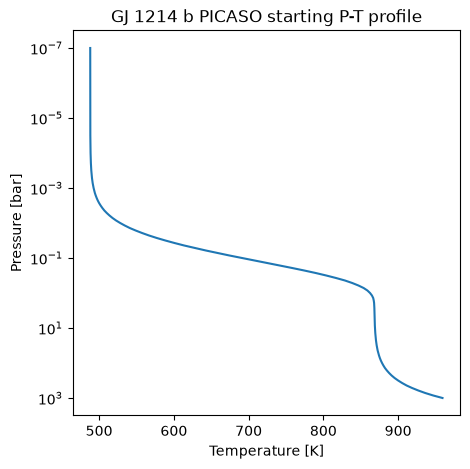

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(pt["temperature"], pt["pressure"])
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("GJ 1214 b PICASO starting P-T profile")
plt.show()

This is only the starting pressure-temperature structure. No Caligo haze particles have been added.

# 8. Photochem: get a MUSCLES spectrum for GJ 1214

Photochem has a very handy stellar helper.

`muscles_spectrum()` can:

- download a MUSCLES spectrum from MAST;
- extend the spectrum to long wavelengths;
- scale the total flux to the planet;
- save it directly in Photochem's stellar-flux format.

GJ 1214 is already one of the supported MUSCLES stars.

In [20]:
import pandas as pd
from photochem.utils import stars

def stellar_class(teff):
    if teff is None:
        return "Unknown"
    if teff >= 6000:
        return "F"
    elif teff >= 5200:
        return "G"
    elif teff >= 3700:
        return "K"
    else:
        return "M"

star_list = []

for name, info in stars.MUSCLES_STARS.items():
    star_list.append({
        "Star name": name,
        "Approx. type": stellar_class(info["st_teff"]),
        "Teff [K]": info["st_teff"],
        "Radius [Rsun]": info["st_rad"],
        "[Fe/H]": info["st_met"],
        "log(g)": info["st_logg"],
    })

muscles_stars = pd.DataFrame(star_list)
muscles_stars = muscles_stars.sort_values("Teff [K]")

display(muscles_stars)

,Star name,Approx. type,Teff [K],Radius [Rsun],[Fe/H],log(g)
28,TRAPPIST-1,M,2566.00,0.12,0.053,5.24
6,GJ551,M,2900.00,0.14,NaN,5.16
26,LP-791-18,M,2960.00,0.18,-0.090,5.12
1,GJ1214,M,3101.00,0.22,0.240,5.03
12,GJ699,M,3195.00,0.18,-0.560,4.90
25,LHS-2686,M,3220.00,NaN,NaN,NaN
0,GJ1132,M,3229.00,0.22,-0.170,5.04
13,GJ729,M,3240.00,NaN,NaN,NaN
24,L-980-5,M,3278.00,NaN,NaN,NaN
16,GJ876,M,3293.74,0.37,0.213,4.87


In [21]:
from photochem.utils import stars

print("GJ1214 in the Photochem MUSCLES table:")
print(stars.MUSCLES_STARS["GJ1214"])

GJ1214 in the Photochem MUSCLES table:
{'st_logg': 5.03, 'st_met': 0.24, 'st_rad': 0.22, 'st_teff': 3101.0}


The simplest way to scale the spectrum is to pass the planet's **zero-albedo equilibrium temperature** calculated above.

In [22]:
star_name = "GJ1214"

print("Selected star:", star_name)
print(stars.MUSCLES_STARS[star_name])


muscles_file = f"{star_name}_MUSCLES.txt"

wv, flux = stars.muscles_spectrum(
    star_name,
    outputfile=muscles_file,
    Teq=planet_Teq,
)

print("Saved:", muscles_file)

Selected star: GJ1214
{'st_logg': 5.03, 'st_met': 0.24, 'st_rad': 0.22, 'st_teff': 3101.0}
Saved: GJ1214_MUSCLES.txt


In [23]:
import importlib.metadata as metadata
import inspect
from photochem.utils import stars

print("Photochem version:", metadata.version("photochem"))
print("muscles_spectrum:", inspect.signature(stars.muscles_spectrum))

Photochem version: 0.8.4
muscles_spectrum: (star_name, outputfile=None, Teq=None, stellar_flux=None, needed_resolution=True, verbose=True)


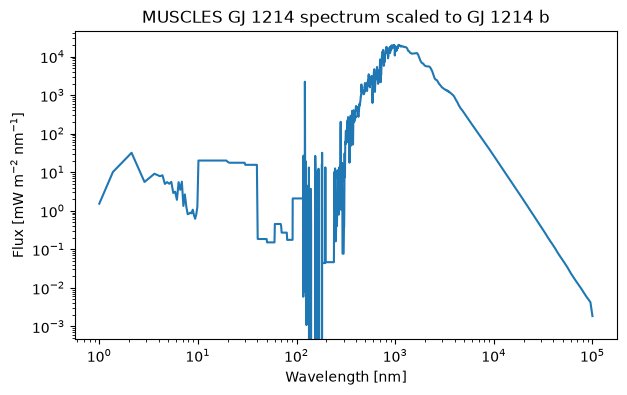

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(wv, flux)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Flux [mW m$^{-2}$ nm$^{-1}$]")
ax.set_title("MUSCLES GJ 1214 spectrum scaled to GJ 1214 b")
plt.show()

### Different orbital distance

For the same star, changing the orbital distance only changes the amount of stellar flux reaching the planet.

Photochem can also take `stellar_flux=` instead of `Teq=` if the incident flux is already known.

### Different stellar type

Available MUSCLES stars can be printed with:

```python
stars.print_muscles_stars()
```

If the exact star is not available, a nearby effective-temperature match can be found with:

```python
stars.closest_muscles_to_Teff(3500)
```

A temperature match is a useful proxy, but it does not guarantee the same UV activity. That matters for photochemistry.

## 8.1 Check the PICASO ↔ Photochem interface

PICASO includes a helper that builds the reaction and thermodynamic files used by its Photochem coupling.

If this cell works, PICASO and Photochem are talking to each other correctly.

In [25]:
import picaso.photochem as picasochem

picasochem.generate_photochem_rx_and_thermo_files()

print("photochem_rxns.yaml:", Path("photochem_rxns.yaml").exists())
print("photochem_thermo.yaml:", Path("photochem_thermo.yaml").exists())

photochem_rxns.yaml: True
photochem_thermo.yaml: True


A full PICASO + Photochem climate run needs the stellar spectrum, reaction files, pressure-temperature profile, boundary conditions, and a choice for vertical mixing \(K_{zz}\). That full calculation belongs in the science tutorial rather than the installation test.

The important checks here are:

- Photochem imports;
- its data package is present;
- MUSCLES can provide the stellar spectrum;
- PICASO can generate the Photochem mechanism files.

# 9. VIRGA: a tiny cloud-model test

VIRGA models **condensate clouds**, not photochemical haze.

A tiny isothermal atmosphere is enough to make sure the code and `.mieff` files work together.

In [26]:
pressure = np.logspace(-5, 3, 30)
temperature = np.full(30, 1600.0)

recommended = vjdi.recommend_gas(
    pressure,
    temperature,
    1.0,   # 1x solar metallicity
    2.2,   # H2-dominated mean molecular weight
)

print("VIRGA recommends:")
print(recommended)

VIRGA recommends:
[np.str_('CaAl12O19'), np.str_('CaTiO3'), np.str_('Cr'), np.str_('Fe'), np.str_('Mg2SiO4'), np.str_('MgSiO3'), np.str_('SiO2'), np.str_('TiO2')]


In [27]:
virga_test = vjdi.Atmosphere(
    ["MgSiO3"],
    fsed=0.5,
    mh=1.0,
    mmw=2.2,
)

virga_test.gravity(
    gravity=357.0,
    gravity_unit=u.Unit("cm / s**2"),
)

virga_pt = pd.DataFrame({
    "pressure": pressure,
    "temperature": temperature,
})

virga_test.ptk(
    df=virga_pt,
    constant_kz=1e10,
)

virga_output = virga_test.compute(
    as_dict=True,
    directory=str(MIEFF_DIR),
)

print("VIRGA cloud calculation worked.")
print(virga_output.keys())

Not doing sublayer as cloud deck at the bottom of pressure grid
VIRGA cloud calculation worked.
dict_keys(['pressure', 'pressure_unit', 'temperature', 'temperature_unit', 'wave', 'wave_unit', 'condensate_mmr', 'cond_plus_gas_mmr', 'mean_particle_r', 'droplet_eff_r', 'r_units', 'column_density', 'column_density_unit', 'opd_per_layer', 'single_scattering', 'asymmetry', 'opd_by_gas', 'condensibles', 'scalar_inputs', 'fsed', 'altitude', 'layer_thickness', 'z_unit', 'mixing_length', 'mixing_length_unit', 'kz', 'kz_unit', 'scale_height', 'cloud_deck'])


That is the basic VIRGA pattern:

```text
P-T profile + Kzz
        ↓
choose condensate(s)
        ↓
choose fsed
        ↓
VIRGA reads the .mieff optical grid
        ↓
cloud particle and optical properties
```

The full Caligo tutorial will start from the same kind of atmospheric background, but the haze particles will be evolved with Caligo's microphysical model instead.

# 10. Final check

If the important lines below return `True`, the setup is ready for the Caligo notebook.

In [28]:
checks = {
    "PICASO reference folder": (PICASO_REFDATA / "config.json").exists(),
    "PICASO resampled opacity": len(opacity_files) > 0,
    "PICASO stellar grid": (PYSYN_CDBS / "grid").exists(),
    "PICASO resortrebin tables": len(ck_files) > 0,
    "VIRGA mieff files": len(mieff_files) > 0,
    "Photochem data": Path(DATA_DIR).exists(),
    "MUSCLES spectrum": Path(muscles_file).exists(),
}

for name, passed in checks.items():
    print(("✓" if passed else "✗"), name)

✓ PICASO reference folder
✓ PICASO resampled opacity
✓ PICASO stellar grid
✓ PICASO resortrebin tables
✓ VIRGA mieff files
✓ Photochem data
✓ MUSCLES spectrum


## Ready for Caligo

At this point:

- PICASO can build the atmospheric background and handle radiative transfer;
- Photochem can provide disequilibrium chemistry and a planet-scaled stellar UV spectrum;
- VIRGA can model equilibrium condensate clouds;
- all three packages work inside the same Caligo environment.

The next notebook can focus only on what Caligo adds: **haze production, particle growth, transport, settling, and optical properties.**